In [90]:
!pip install pandas numpy
!pip install matplotlib seaborn scikit-learn xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [92]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [93]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
# string -> num
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# lỗi -> nan in ra count
print(f"Num of Nan in TotalCharges: {df["TotalCharges"].isna().sum()}")

df["TotalCharges"].fillna(0, inplace = True)

df.dropna(inplace=True)

df.drop(columns = ["customerID"], inplace = True)

df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(f"Churn rate: {df["Churn"].mean():.2%}")

Num of Nan in TotalCharges: 11
Churn rate: 26.58%


/var/folders/62/5htmk9jd5jb928zxq_mxntgc0000gn/T/ipykernel_72689/3947622761.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(0, inplace = True)


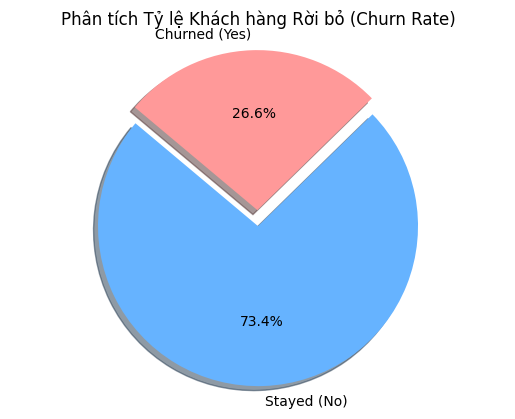

In [95]:
churn_counts = df["Churn"].value_counts()
labels = ['Stayed (No)', 'Churned (Yes)']
colors = ['#66b3ff', '#ff9999'] # Xanh cho ở lại, Đỏ cho rời đi
explode = (0, 0.1)  # Làm nổi bật phần khách hàng rời đi

plt.pie(churn_counts, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode, 
        shadow=True)

plt.title('Phân tích Tỷ lệ Khách hàng Rời bỏ (Churn Rate)')
plt.axis('equal') 

# Lưu biểu đồ thành file ảnh
plt.savefig('../images/churn_pie_chart.png')

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Churn rate by categorical column:

gender:
gender
Female    0.269595
Male      0.262046
Name: Churn, dtype: float64

Partner:
Partner
No     0.329761
Yes    0.197171
Name: Churn, dtype: float64

Dependents:
Dependents
No     0.312791
Yes    0.155312
Name: Churn, dtype: float64

PhoneService:
PhoneService
Yes    0.267475
No     0.250000
Name: Churn, dtype: float64

MultipleLines:
MultipleLines
Yes                 0.286485
No                  0.250812
No phone service    0.250000
Name: Churn, dtype: float64

InternetService:
InternetService
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: Churn, dtype: float64

OnlineSecuri

/var/folders/62/5htmk9jd5jb928zxq_mxntgc0000gn/T/ipykernel_72689/3008503147.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


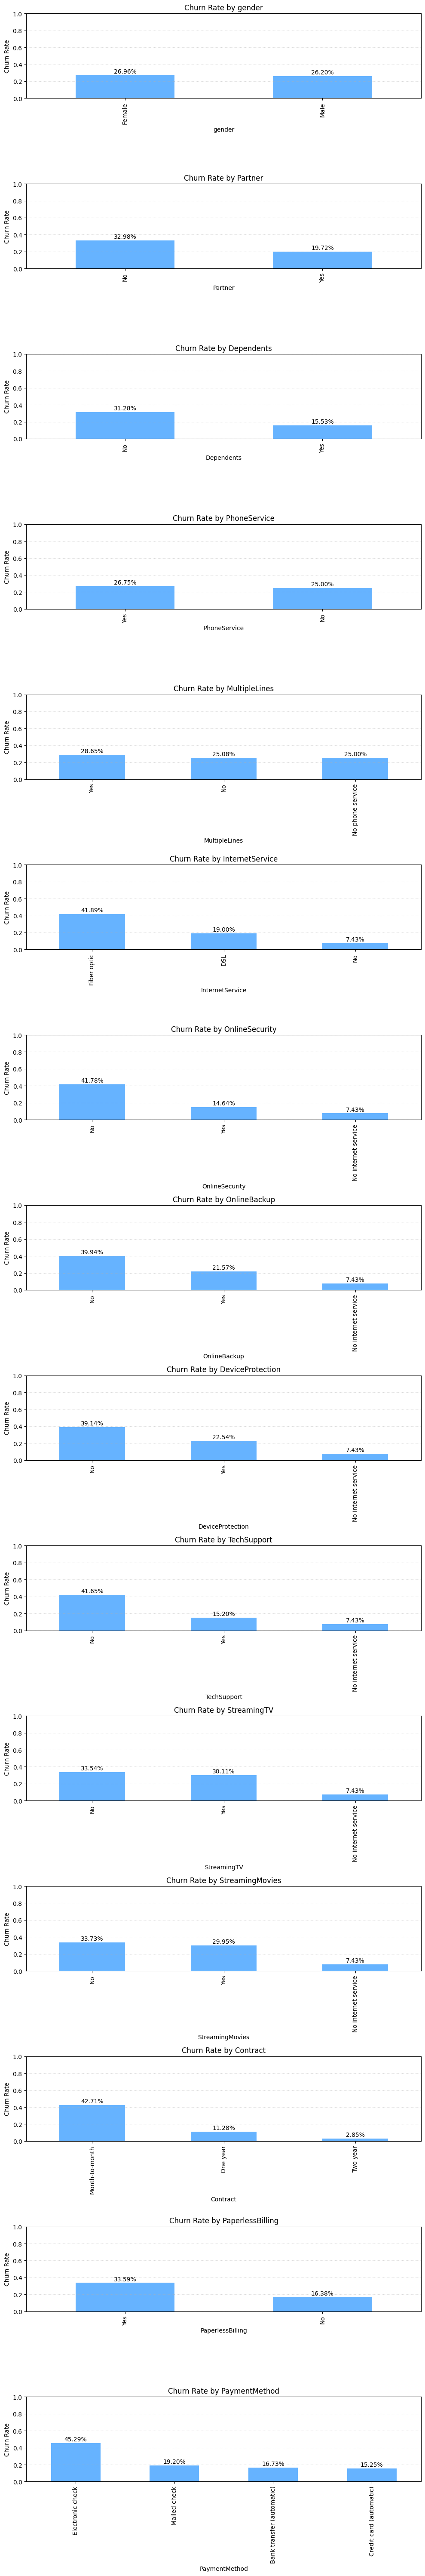

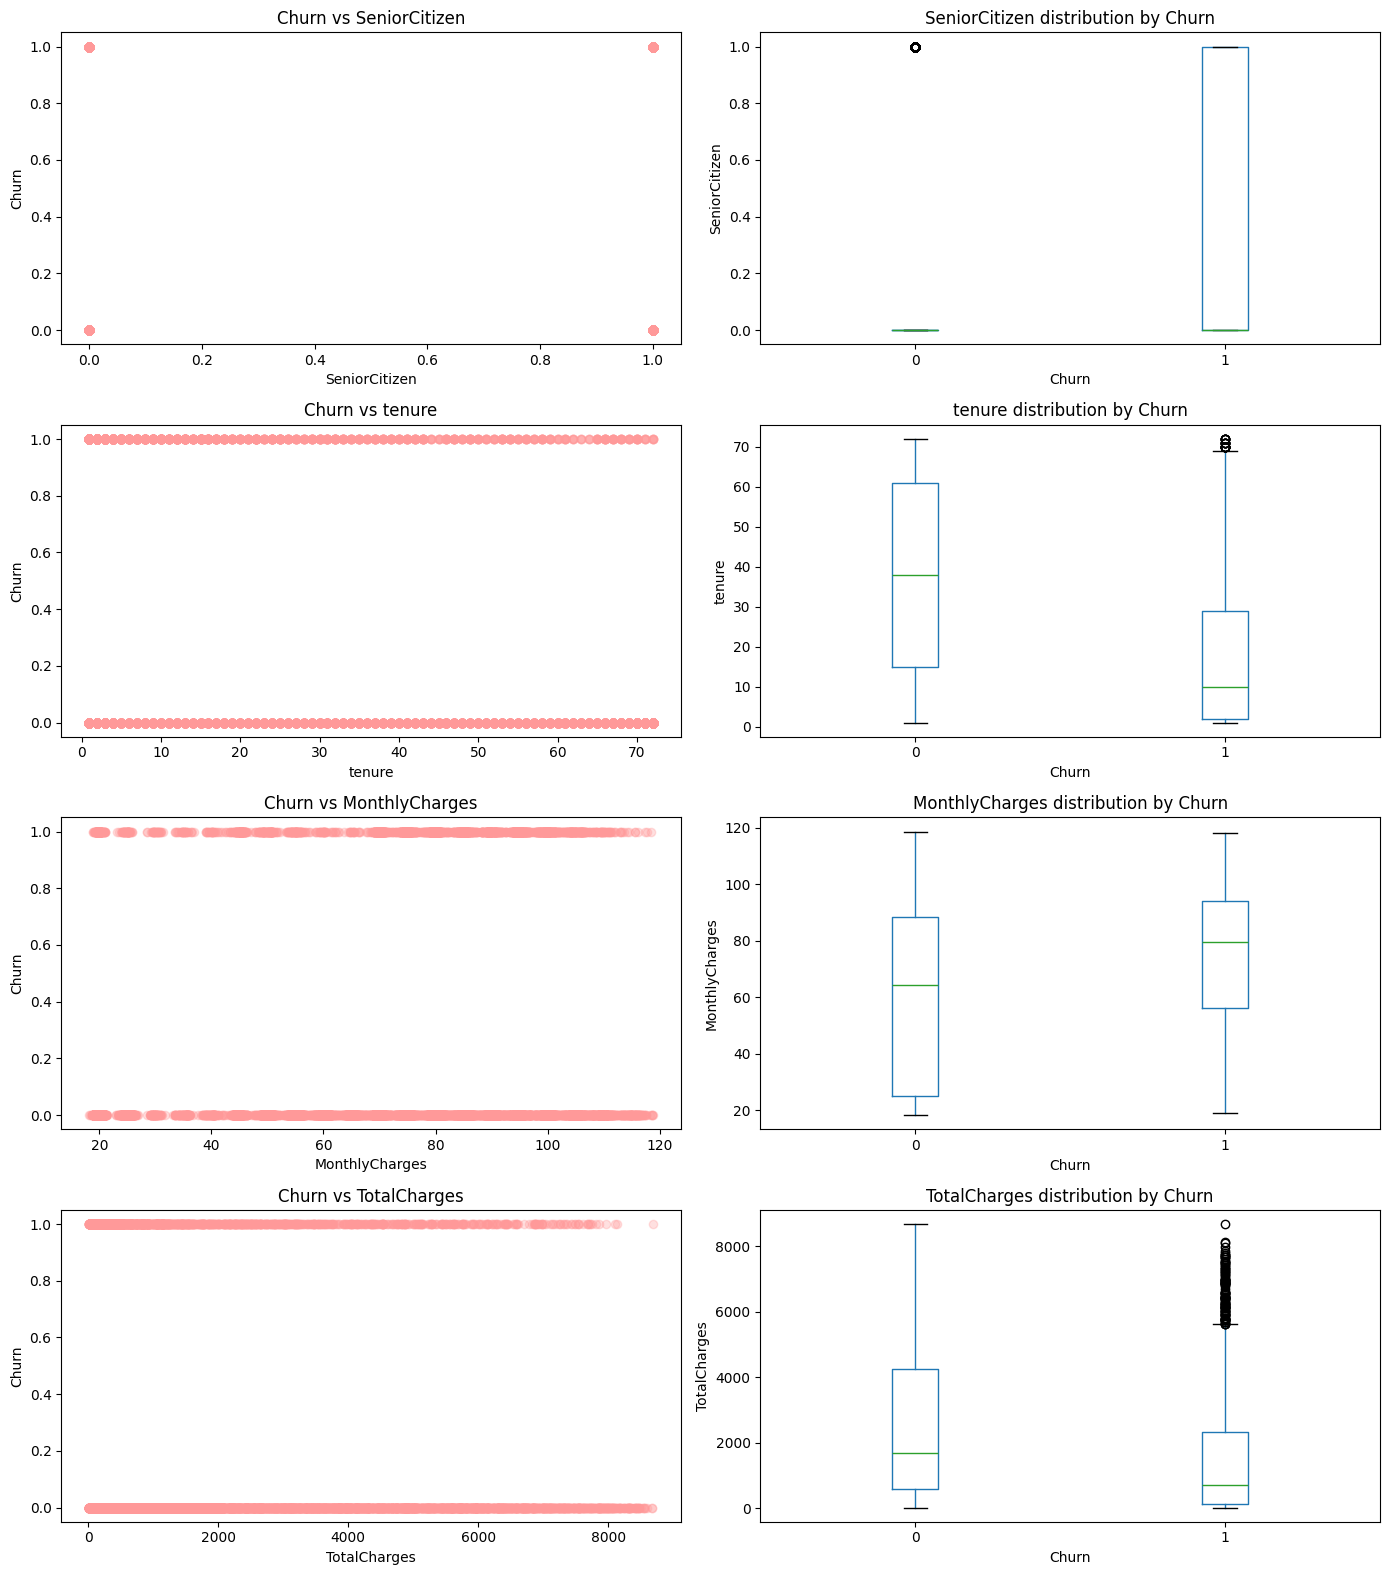

In [96]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != "Churn"]

print("Categorical columns:")
print(categorical_cols)
print("\nNumeric columns:")
print(numeric_cols)

print("\nChurn rate by categorical column:")
for col in categorical_cols:
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    print(churn_rate)

# Plot churn rate for categorical columns
n_cat = len(categorical_cols)
fig, axes = plt.subplots(n_cat, 1, figsize=(10, 4 * n_cat))
if n_cat == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=ax, color="#66b3ff")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    # Add percentage labels on bars
    for i, v in enumerate(churn_rate):
        ax.text(i, v + 0.01, f'{v:.2%}', ha='center', va='bottom')

plt.tight_layout()

# Plot numeric dependency with scatter and boxplot
n_num = len(numeric_cols)
fig, axes = plt.subplots(n_num, 2, figsize=(14, 4 * n_num))
for i, col in enumerate(numeric_cols):
    ax_scatter = axes[i, 0]
    ax_box = axes[i, 1]
    ax_scatter.scatter(df[col], df["Churn"], alpha=0.3, color="#ff9999")
    ax_scatter.set_title(f"Churn vs {col}")
    ax_scatter.set_xlabel(col)
    ax_scatter.set_ylabel("Churn")

    df.boxplot(column=col, by="Churn", ax=ax_box, grid=False)
    ax_box.set_title(f"{col} distribution by Churn")
    ax_box.set_xlabel("Churn")
    ax_box.set_ylabel(col)

plt.suptitle("")
plt.tight_layout()

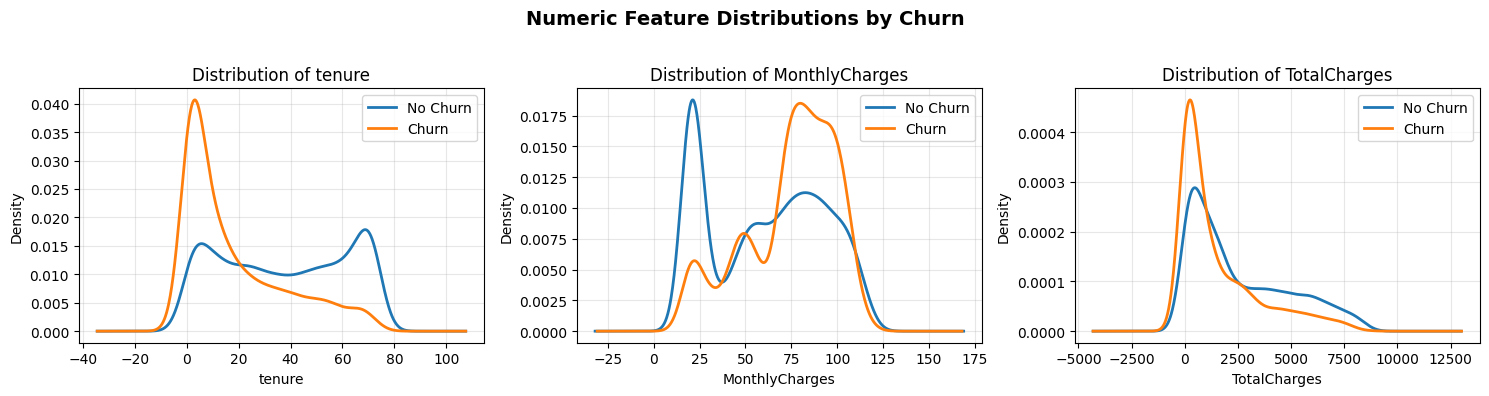

In [97]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby("Churn"):
        grp[col].plot.kde(ax=ax, label=["No Churn", "Churn"][label], linewidth=2)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Numeric Feature Distributions by Churn", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../images/plot_numeric_dist.png")
plt.show()

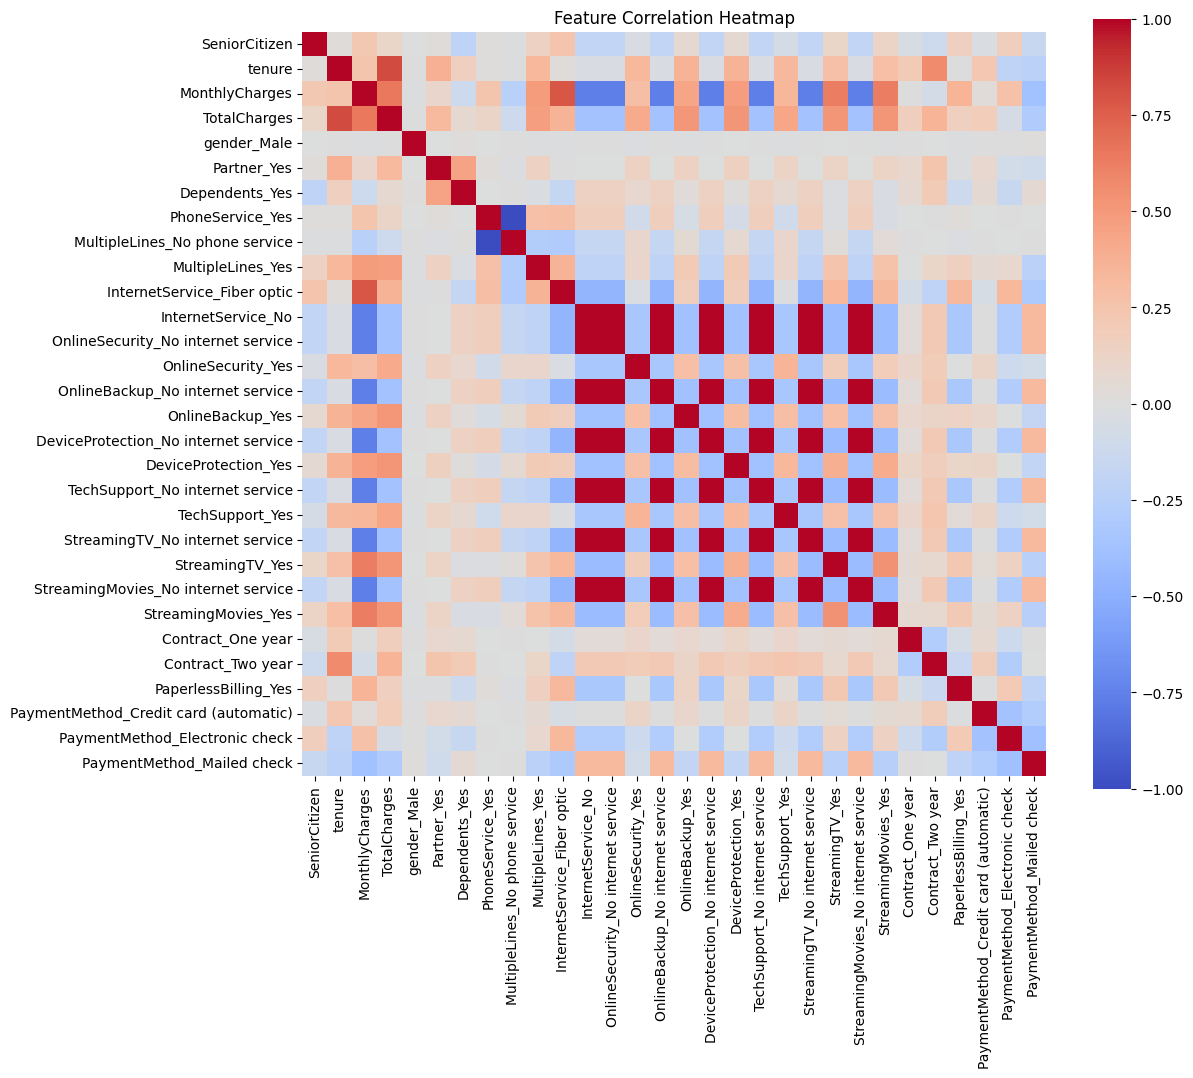

In [98]:
import seaborn as sns

# Compute correlation matrix for encoded features
corr = X_encoded.corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

/var/folders/62/5htmk9jd5jb928zxq_mxntgc0000gn/T/ipykernel_72689/1535156268.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_corr.select_dtypes("object").columns:


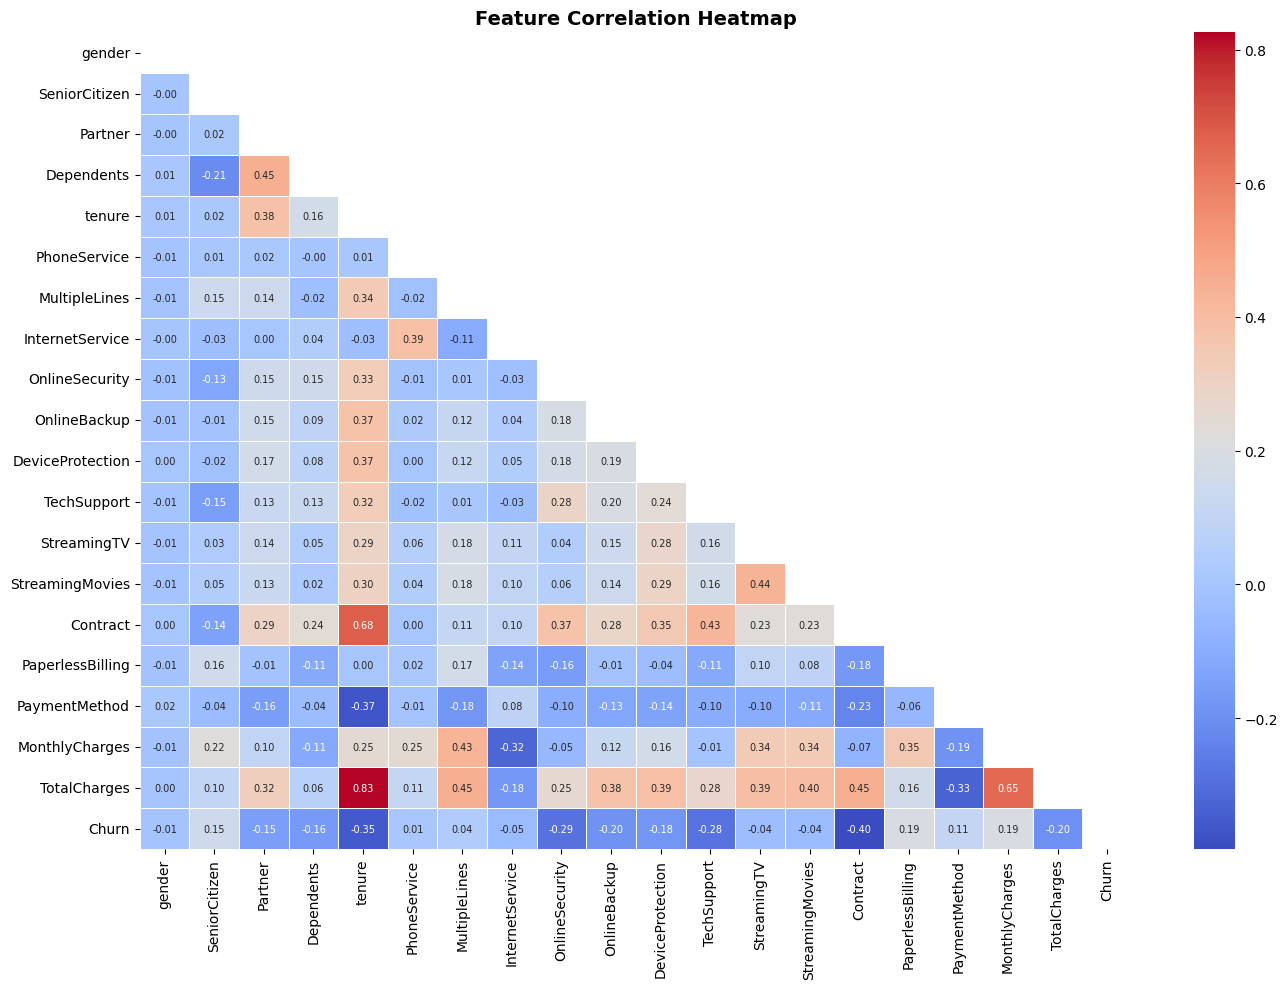

In [99]:
from sklearn.preprocessing import LabelEncoder

# Correlation heatmap (numeric + encoded binary)
df_corr = df.copy()
for c in df_corr.select_dtypes("object").columns:
    df_corr[c] = LabelEncoder().fit_transform(df_corr[c])
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14,10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size":7})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/plot_heatmap.png")
plt.show()

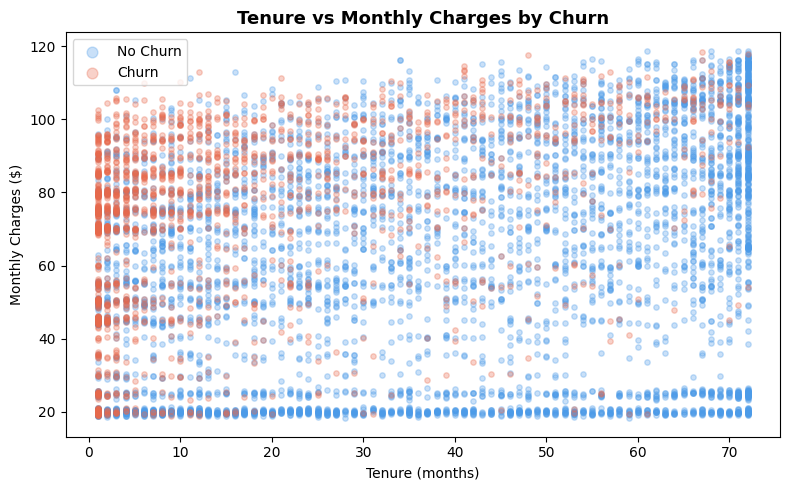

In [100]:
# Tenure vs MonthlyCharges scatter coloured by churn
fig, ax = plt.subplots(figsize=(8,5))
colors = {0:"#4C9BE8", 1:"#E8694C"}
for label, grp in df.groupby("Churn"):
    ax.scatter(grp["tenure"], grp["MonthlyCharges"], alpha=0.3, s=15,
               c=colors[label], label=["No Churn","Churn"][label])
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Monthly Charges ($)")
ax.set_title("Tenure vs Monthly Charges by Churn", fontsize=13, fontweight="bold")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("../images/plot_scatter.png")
plt.show()

In [101]:
df_model = df.copy()

# Binary yes/no cols
binary_cols = [c for c in df_model.select_dtypes("object").columns
               if set(df_model[c].unique()) <= {"Yes","No"}]
for c in binary_cols:
    df_model[c] = (df_model[c] == "Yes").astype(int)

# One-hot encode remaining categoricals
df_model = pd.get_dummies(df_model, drop_first=True)

print(f"Features after encoding: {df_model.shape[1]-1}")
df_model.head(3)

Features after encoding: 30


/var/folders/62/5htmk9jd5jb928zxq_mxntgc0000gn/T/ipykernel_72689/2281114813.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  binary_cols = [c for c in df_model.select_dtypes("object").columns


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True


In [102]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 5625 | Test: 1407


In [103]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=50, random_state=42),
}

results = {}
for name, model in models.items():
    # Use scaled data for Logistic Regression, unscaled for others
    Xtr, Xte = (X_train_s, X_test_s) if "Logistic" in name else (X_train, X_test)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, proba)
    results[name] = {"model": model, "preds": preds, "proba": proba, "auc": auc}
    
    print(f"\n=== {name} (AUC={auc:.4f}) ===")
    print(classification_report(y_test, preds, target_names=["No Churn", "Churn"]))
    
    # Print feature importance only for models that have it
    if hasattr(model, 'feature_importances_'):
        importance = pd.Series(model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(10)
        print("Top 10 feature importances:")
        print(importance)
    elif "Logistic" in name:
        # For Logistic Regression, use coefficients
        importance = pd.Series(model.coef_[0], index=X_encoded.columns).abs().sort_values(ascending=False).head(10)
        print("Top 10 feature coefficients (absolute values):")
        print(importance)


=== Logistic Regression (AUC=0.8350) ===
              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

Top 10 feature coefficients (absolute values):
TotalCharges                           1.263854
Dependents_Yes                         0.928682
InternetService_No                     0.746144
PaperlessBilling_Yes                   0.638598
PhoneService_Yes                       0.623279
Contract_Two year                      0.326693
StreamingMovies_No internet service    0.259691
Contract_One year                      0.252870
InternetService_Fiber optic            0.202763
PaymentMethod_Electronic check         0.193697
dtype: float64

=== Random Forest (AUC=0.8150) ===
              precision    recall  f1-score   support

In [104]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

importance_xgb = pd.Series(model_xgb.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(10)
print("Top 10 feature importances (XGBoost):")
print(importance_xgb)

XGBoost Accuracy: 0.7782515991471215
XGBoost ROC AUC: 0.8196468413995888
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

Top 10 feature importances (XGBoost):
InternetService_No                     0.428601
PaperlessBilling_Yes                   0.183019
Contract_Two year                      0.095891
OnlineSecurity_No internet service     0.053473
Contract_One year                      0.023632
TotalCharges                           0.023485
OnlineBackup_No internet service       0.015021
PaymentMethod_Electronic check         0.014857
InternetService_Fiber optic            0.013777
StreamingMovies_No internet service    0.013468
dtype: float32


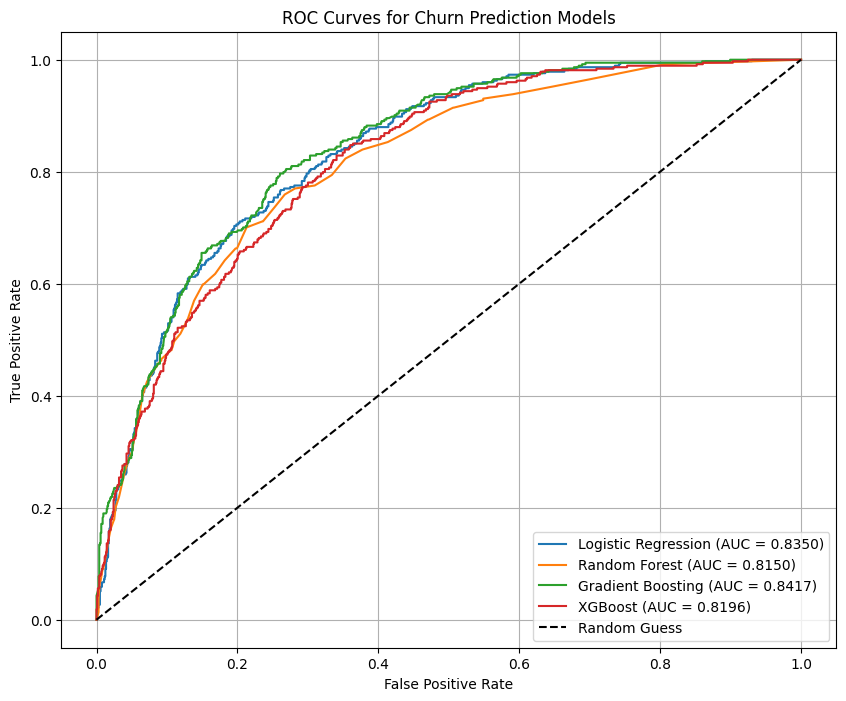

In [105]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["auc"]:.4f})')

# Also add XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Churn Prediction Models')
plt.legend()
plt.grid(True)
plt.show()

In [110]:
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
classifiers = [
    (
        "Logistic Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
        ]),
        {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
            "clf__solver": ["liblinear", "saga"]
        }
    ),
    (
        "Random Forest",
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        {
            "n_estimators": [50, 100, 150],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    ),
    (
        "Gradient Boosting",
        GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    ),
    (
        "XGBoost",
        XGBClassifier(random_state=42, eval_metric="logloss"),
        {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
            "subsample": [0.8, 1.0]
        }
    ),
    
    
]

# ====================== HÀM TỐI ƯU SIÊU THAM SỐ (GIỮ NGUYÊN) ======================
def hyperparameter_optimization(classifiers_list, X, y, cv=5, scoring="roc_auc"):
    print("Hyperparameter Optimization")
    best_models = {}
    
    for name, classifier, params in classifiers_list:
        print(f"########## {name} #########")
        
        # Đánh giá trước tối ưu
        cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        print(f"{scoring} (Before): {cv_results['test_score'].mean():.4f}")

        # Grid Search
        gs_best = GridSearchCV(
            estimator=classifier,
            param_grid=params,
            cv=cv,
            n_jobs=-1,
            verbose=0,
            scoring=scoring
        ).fit(X, y)

        final_model = gs_best.best_estimator_

        # Đánh giá sau tối ưu
        cv_results = cross_validate(final_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        print(f"{scoring} (After) : {cv_results['test_score'].mean():.4f}")
        print(f"{name} best params: {gs_best.best_params_}\n")
        
        best_models[name] = final_model
    
    return best_models


# ====================== CHẠY TỐI ƯU ======================
best_models = hyperparameter_optimization(classifiers, X_train, y_train, cv=5, scoring="roc_auc")

# ====================== ĐÁNH GIÁ TRÊN TEST SET ======================
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n=== {name} on holdout test set ===")
    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Hyperparameter Optimization
########## Logistic Regression #########
roc_auc (Before): 0.8457


/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: 

roc_auc (After) : 0.8458
Logistic Regression best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}

########## Random Forest #########
roc_auc (Before): 0.8281
roc_auc (After) : 0.8445
Random Forest best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}

########## Gradient Boosting #########
roc_auc (Before): 0.8462
roc_auc (After) : 0.8467
Gradient Boosting best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

########## XGBoost #########
roc_auc (Before): 0.8261
roc_auc (After) : 0.8487
XGBoost best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


=== Logistic Regression on holdout test set ===
ROC AUC: 0.8343
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weig

In [ ]:
mlp_classifier = [
    (
        "MLP (Neural Network)",
        Pipeline([
            ("scaler", StandardScaler()),          # Bắt buộc với MLP
            ("clf", MLPClassifier(random_state=42, max_iter=500))
        ]),
        {
            "clf__hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50)],
            "clf__activation": ["relu", "tanh"],
            "clf__solver": ["adam"],
            "clf__alpha": [0.0001, 0.001, 0.01],
            "clf__learning_rate_init": [0.001, 0.01],
        }
    ),
]

mlp_best = hyperparameter_optimization(mlp_classifier, X_train, y_train, cv=5, scoring="roc_auc")
mlp_model = mlp_best["MLP (Neural Network)"]
y_pred = mlp_model.predict(X_test)
y_proba = mlp_model.predict_proba(X_test)[:, 1]

print(f"\n=== MLP (Neural Network)" on holdout test set ===")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


Hyperparameter Optimization
########## MLP (Neural Network) #########


/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: M

roc_auc (Before): 0.7920


/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: M

roc_auc (After) : 0.8025
MLP (Neural Network) best params: {'clf__activation': 'relu', 'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (50,), 'clf__learning_rate_init': 0.001, 'clf__solver': 'adam'}


=== XGBoost on holdout test set ===
ROC AUC: 0.8091
              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.85      1033
       Churn       0.60      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



/Users/phamxuanbac/Downloads/mining/assignment_1/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
